In [20]:
import numpy as np
from qutip import *

# -------------------
# PARAMETERS
# -------------------
N = 10 
S = N/2                 # number of spins             
n_ph = 12              # cavity cutoff
hbar = 1.0              # set hbar = 1 for simplicity
J = 1.0
h = 0.5                 # can later make time-dependent
g = 1
omega = 1.0

# -------------------
# SPIN OPERATORS (collective)
# -------------------
Sx = jmat(S, 'x')
Sz = jmat(S, 'z')
S_z2 = Sz * Sz

# Identity operators
I_spin = qeye(N+1)
I_ph = qeye(n_ph)

# -------------------
# CAVITY OPERATORS
# -------------------
a = destroy(n_ph)
adag = a.dag()

# -------------------
# TENSOR SPACE
# -------------------
#Sx_full = tensor(Sx, I_cav)
#Sz_full = tensor(Sz, I_cav)

#a_full = tensor(I_spin, a)
#adag_full = tensor(I_spin, adag)

# -------------------
# HAMILTONIAN TERMS
# -------------------

# LMG part
h_lmg = -(4J/(N+1)) * tensor(S_z2,I_ph) + 2*h*tensor(Sx,I_ph) + hbar*omega*tensor(I_spin,adag*a)

# Interaction
h_d = (2*g/np.sqrt(N)) * tensor(Sx,a + adag)

# Total Hamiltonian
H = h_lmg + h_d

print("Hilbert space dimension:", H.shape)

Hilbert space dimension: (132, 132)


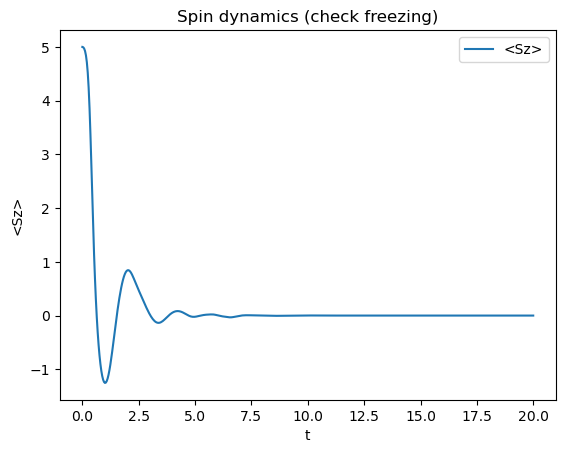

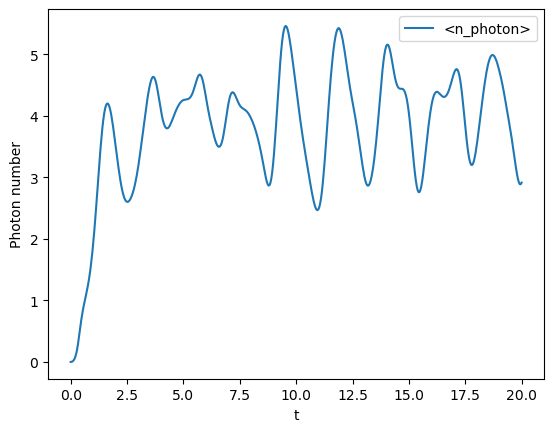

In [21]:
from qutip import *
import numpy as np
from itertools import combinations
from scipy.special import jn_zeros
h0 = 0.5
omega = 1.0
def h_t(t, args):
    h0 = args['h0']
    w = args['omega']
    return h0 * np.cos(w * t)

# Time independent part of the Hamiltonian
H0 = -(4J/(N+1)) * tensor(S_z2,I_ph) + hbar*omega*tensor(I_spin,adag*a) + (2*g/np.sqrt(N)) * tensor(Sx,a + adag)

# Time dependent part of the Hamiltonian
H1 = 2 * tensor(Sx, I_ph)

H_td = [H0, [H1, h_t]]

args = {'h0': h0, 'omega': omega}

# Initial state: all spins up and no photons
psi_spin = basis(N+1, 0)
psi_ph = basis(n_ph, 0)
psi0 = tensor(psi_spin, psi_ph)

# observables: photon number, Sx
op_nph = tensor(I_spin,adag*a)
op_Sx  = tensor(Sx, I_ph)
op_Sz = tensor(Sz, I_ph)
op_Sz2 = tensor(S_z2, I_ph)

# evolve
tlist = np.linspace(0, 20, 500)
opts = Options(nsteps=1e5)
result = mesolve(H_td, psi0, tlist, [], [], args=args)

Sz_exp = expect(op_Sz, result.states)
photon_num = expect(op_nph, result.states)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(tlist, Sz_exp, label='<Sz>')
plt.xlabel('t')
plt.ylabel('<Sz>')
plt.legend()
plt.title('Spin dynamics (check freezing)')
plt.show()

plt.figure()
plt.plot(tlist, photon_num, label='<n_photon>')
plt.xlabel('t')
plt.ylabel('Photon number')
plt.legend()
plt.show()